# Tigramite Integration

Run tigramite's discovery algorithms (PCMCI+, PCMCI, LPCMCI, PC-stable, etc.) from within causal-ts and feed results directly into the full effects/forecasting/query pipeline.

**Features demonstrated:**
1. PCMCI+ with tigramite's ParCorr (+ CDNOTS baseline comparison)
2. PCMCI+ with causal-ts GPU CI tests (SplitKCIGPU, ParCorrGPU)
3. LPCMCI for latent confounder detection
4. Generic dispatcher (`run_tigramite`) for other algorithms
5. Head-to-head comparison: CDNOTS vs PCMCI+ vs PCMCI on ex3
6. Downstream integration: effects, queries, forecasting on tigramite outputs

In [5]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.synthetic_data.synthetic_datasets import ex2, ex3
from causalts.utils import evaluate_graph
import causalts.plotting as tp

## 1. PCMCI+ with Tigramite's ParCorr

The simplest usage — pass a string CI test name and get a standard binary graph back.

In [24]:
from causalts import run_pcmciplus, run_cdnots, run_cdnots_plus
from causalts.ci_tests import PartialCorr

result = ex2(seed=42, T=300)
df = result['df']
true_graph = result['ground_truth']
var_names = df.columns.tolist()
print(f'{result["name"]}, T={len(df)}, max_lag={result["max_lag"]}')

# Run PCMCI+ with tigramite's ParCorr
G_pcmci, info = run_pcmciplus(df, tau_max=3, ci_test='parcorr', pc_alpha=0.01)
m_pcmci = evaluate_graph(G_pcmci, true_graph)

# Run CDNOTS as baseline
ci = PartialCorr(data=df.values)
_res = run_cdnots_plus(df, ci, num_lags=3, include_C=False, alpha=0.01)
G_cdnots_ex2 = _res.cg_tig
m_cdnots = evaluate_graph(G_cdnots_ex2, true_graph)

print(f'\n{"Method":<12} {"F1":>6} {"Prec":>6} {"Rec":>6} {"SHD":>5} {"Edges":>6}')
print('-' * 45)
print(f'{"PCMCI+":<12} {m_pcmci["F1"]:>6.3f} {m_pcmci["Precision"]:>6.3f} '
      f'{m_pcmci["TPR"]:>6.3f} {m_pcmci["SHD"]:>5} {int(G_pcmci.sum()):>6}')
print(f'{"CDNOTS+":<12} {m_cdnots["F1"]:>6.3f} {m_cdnots["Precision"]:>6.3f} '
      f'{m_cdnots["TPR"]:>6.3f} {m_cdnots["SHD"]:>5} {int(G_cdnots_ex2.sum()):>6}')

6-Node Linear VAR, T=300, max_lag=3

Method           F1   Prec    Rec   SHD  Edges
---------------------------------------------
PCMCI+        0.909  0.909  0.909     2     11
CDNOTS+       0.909  0.909  0.909     2     11


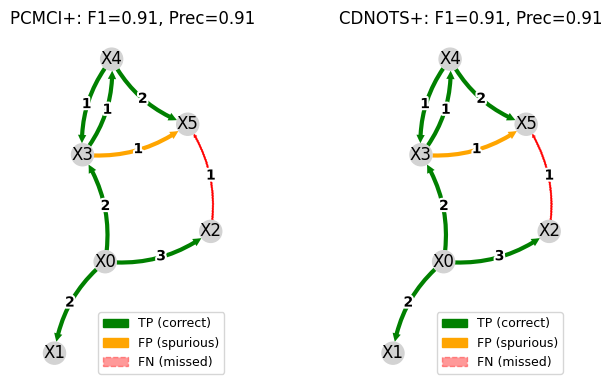

In [7]:
# Side-by-side: PCMCI+ vs CDNOTS on ex2
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

pos = tp.compare_graphs(
    true_graph, G_pcmci, var_names=var_names,
    fig_ax=(fig, axes[0]),
    node_layout='neato', node_size=0.15,
    title=f'PCMCI+: F1={m_pcmci["F1"]:.2f}, Prec={m_pcmci["Precision"]:.2f}',
    legend_loc='lower right', arrow_linewidth=3,
    return_pos=True,
)

tp.compare_graphs(
    true_graph, G_cdnots_ex2, var_names=var_names,
    fig_ax=(fig, axes[1]),
    node_layout='fdp', node_size=0.15,
    legend_loc='lower right',
    node_pos=pos[2],arrow_linewidth=3,
    title=f'CDNOTS+: F1={m_cdnots["F1"]:.2f}, Prec={m_cdnots["Precision"]:.2f}',
)

plt.tight_layout(); plt.show()

## 2. PCMCI+ with Causal-TS GPU CI Tests

Pass any `CIT_Base` GPU test directly — the adapter wraps it automatically for tigramite.

This lets you use causal-ts's GPU-accelerated tests (SplitKCI, KCI, DFCIT, etc.) with PCMCI+'s discovery algorithm.

In [8]:
from causalts.ci_tests import ParCorrGPU

# ParCorrGPU — GPU-accelerated partial correlation
gpu_parcorr = ParCorrGPU(data=df.values, device='cpu')
G_gpu_parcorr, info_gpu = run_pcmciplus(df, tau_max=3, ci_test=gpu_parcorr, pc_alpha=0.01)

m_gpu = evaluate_graph(G_gpu_parcorr, true_graph)
print(f'PCMCI+ (ParCorrGPU): F1={m_gpu["F1"]:.3f}, '
      f'Precision={m_gpu["Precision"]:.3f}, Recall={m_gpu["TPR"]:.3f}')

PCMCI+ (ParCorrGPU): F1=0.909, Precision=0.909, Recall=0.909


In [9]:
from causalts.ci_tests import SplitKCIGPU, RCOTGPU


# SplitKCIGPU — nonlinear kernel CI test, 10-20x faster than KCI
# Use smaller T for speed since kernel tests are O(T^2)
result_small = ex2(seed=42, T=300)
df_small = result_small['df']

gpu_splitkci = SplitKCIGPU(data=df_small.values, device='cpu')
rcot = RCOTGPU(data=df_small.values, num_f=25, num_f2=10, device='cpu')
G_splitkci, _ = run_pcmciplus(df_small, tau_max=3, ci_test=gpu_splitkci, pc_alpha=0.05)
G_rcot, _ = run_pcmciplus(df_small, tau_max=3, ci_test=rcot, pc_alpha=0.05)

m_sk = evaluate_graph(G_splitkci, true_graph)
m_rcot = evaluate_graph(G_rcot, true_graph)
print(f'PCMCI+ (SplitKCIGPU, T=300): F1={m_sk["F1"]:.3f}, '
      f'Precision={m_sk["Precision"]:.3f}, Recall={m_sk["TPR"]:.3f}')
print(f'PCMCI+ (RCOTGPU, T=300): F1={m_rcot["F1"]:.3f}, '
      f'Precision={m_rcot["Precision"]:.3f}, Recall={m_rcot["TPR"]:.3f}')

PCMCI+ (SplitKCIGPU, T=300): F1=0.800, Precision=0.889, Recall=0.727
PCMCI+ (RCOTGPU, T=300): F1=0.870, Precision=0.833, Recall=0.909


## 3. LPCMCI — Latent Confounder Detection

LPCMCI extends PCMCI+ to handle latent (hidden) confounders. It outputs a Partial Ancestral Graph (PAG) with richer edge types:
- `-->` : definite cause
- `o->` : possible cause (could be confounded)
- `<->` : latent confounder present
- `o-o` : fully undetermined

**Note on the binary output:** The binary `G_hat` conservatively includes both `-->` and `o->` as directed edges. The full PAG with all edge types is preserved in `info["graph_raw"]`, and `info["edge_types"]` gives a count summary. Use the raw PAG when the distinction between definite (`-->`) and possible (`o->`) causes matters.

In [10]:
from causalts import run_lpcmci

G_lpcmci, info_lpc = run_lpcmci(df, tau_max=3, ci_test='parcorr', pc_alpha=0.05)

m_lpc = evaluate_graph(G_lpcmci, true_graph)
print(f'LPCMCI: F1={m_lpc["F1"]:.3f}, Precision={m_lpc["Precision"]:.3f}, '
      f'Recall={m_lpc["TPR"]:.3f}')
print(f'\nEdge types in PAG: {info_lpc["edge_types"]}')
print(f'Binary edges (incl. o->): {int(G_lpcmci.sum())}')
print(f'\nThe full PAG is in info["graph_raw"] (shape {info_lpc["graph_raw"].shape}).')
print('Use it to distinguish definite causes (-->) from possible ones (o->).')

LPCMCI: F1=0.870, Precision=0.833, Recall=0.909

Edge types in PAG: {'-->': 9, '<->': 2, 'o->': 3}
Binary edges (incl. o->): 12

The full PAG is in info["graph_raw"] (shape (6, 6, 4)).
Use it to distinguish definite causes (-->) from possible ones (o->).


In [11]:
# Inspect the raw PAG edge types
raw = info_lpc['graph_raw']
print('PAG edges (non-empty):')
for i in range(raw.shape[0]):
    for j in range(raw.shape[1]):
        for tau in range(raw.shape[2]):
            if raw[i, j, tau] != '':
                marker = ' *' if raw[i, j, tau] in ('o->', '<->', 'o-o') else ''
                print(f'  {var_names[i]}(t-{tau}) {raw[i,j,tau]} {var_names[j]}(t){marker}')

PAG edges (non-empty):
  X0(t-1) --> X0(t)
  X0(t-2) o-> X1(t) *
  X0(t-3) o-> X1(t) *
  X0(t-3) o-> X2(t) *
  X0(t-2) --> X3(t)
  X3(t-1) --> X3(t)
  X3(t-1) --> X4(t)
  X3(t-1) <-> X5(t) *
  X4(t-3) <-> X2(t) *
  X4(t-1) --> X3(t)
  X4(t-1) --> X4(t)
  X4(t-2) --> X5(t)
  X5(t-1) --> X5(t)
  X5(t-2) --> X5(t)


(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'LPCMCI (PAG -> binary): F1=0.87, Prec=0.83'}>)

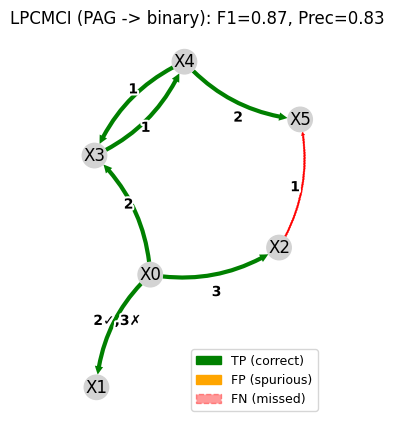

In [12]:
# Visualize LPCMCI discovered graph vs true
tp.compare_graphs(
    true_graph, G_lpcmci, var_names=var_names,
    figsize=(12, 5), node_layout='neato', node_size=0.15,
    legend_loc='lower right', arrow_linewidth=3,
    title=f'LPCMCI (PAG -> binary): F1={m_lpc["F1"]:.2f}, Prec={m_lpc["Precision"]:.2f}',
)

## 4. Generic Dispatcher

`run_tigramite()` is a single entry point for all tigramite algorithms.

In [13]:
from causalts import run_tigramite

methods_to_test = ['pcmciplus', 'pcmci', 'lpcmci']

results = {}
for method in methods_to_test:
    G, info = run_tigramite(df, method=method, tau_max=3, ci_test='parcorr')
    m = evaluate_graph(G, true_graph)
    results[method] = {'G': G, 'info': info, 'metrics': m}
    print(f'{method:12s}: F1={m["F1"]:.3f}, Prec={m["Precision"]:.3f}, '
          f'Rec={m["TPR"]:.3f}, edges={int(G.sum())}')

pcmciplus   : F1=0.909, Prec=0.909, Rec=0.909, edges=11
pcmci       : F1=0.690, Prec=0.556, Rec=0.909, edges=18
lpcmci      : F1=0.870, Prec=0.833, Rec=0.909, edges=12


## 5. Head-to-Head: CDNOTS vs PCMCI

Compare causal-ts's CDNOTS against tigramite's algorithms on ex3 (Cascade Network, 11-Node).

In [14]:
from causalts import run_pcmci

result3 = ex3(seed=42, T=500)
df3 = result3['df']
true3 = result3['ground_truth']
var3 = df3.columns.tolist()
print(f'ex3: d={df3.shape[1]}, T={len(df3)}, true edges={int(true3.sum())}')

# CDNOTS
ci = PartialCorr(data=np.zeros((2, 2)))
_res = run_cdnots(df3, ci, num_lags=3, priority=2,include_C=False, alpha=0.01)
G_cdnots3 = _res.cg_tig
m_cdn = evaluate_graph(G_cdnots3, true3)

# CDNOTS+
ci = PartialCorr(data=np.zeros((2, 2)))
_resp = run_cdnots_plus(df3, ci, num_lags=3, priority=2,include_C=False, alpha=0.01)
G_cdnotsp3 = _resp.cg_tig
m_cdnotsp = evaluate_graph(G_cdnotsp3, true3)

# PCMCI+
G_pcmci3, _ = run_pcmciplus(df3, tau_max=3, ci_test='parcorr', pc_alpha=0.01)
m_pcmci3 = evaluate_graph(G_pcmci3, true3)

# PCMCI
G_pcmci_orig, _ = run_pcmci(df3, tau_max=3, ci_test='parcorr', alpha_level=0.01)
m_pcmci_orig = evaluate_graph(G_pcmci_orig, true3)

print(f'\n{"Method":<12} {"F1":>6} {"Prec":>6} {"Rec":>6} {"SHD":>5} {"Edges":>6}')
print('-' * 50)
for name, m, G in [('CDNOTS+', m_cdnotsp, G_cdnotsp3),
                   ('CDNOTS', m_cdn, G_cdnots3),
                    ('PCMCI+', m_pcmci3, G_pcmci3),
                    ('PCMCI', m_pcmci_orig, G_pcmci_orig)]:
    print(f'{name:<12} {m["F1"]:>6.3f} {m["Precision"]:>6.3f} {m["TPR"]:>6.3f} '
          f'{m["SHD"]:>5} {int(G.sum()):>6}')

ex3: d=11, T=500, true edges=28

Method           F1   Prec    Rec   SHD  Edges
--------------------------------------------------
CDNOTS+       0.982  1.000  0.964     1     27
CDNOTS        0.923  1.000  0.857     4     24
PCMCI+        0.982  1.000  0.964     1     27
PCMCI         0.966  0.933  1.000     2     30


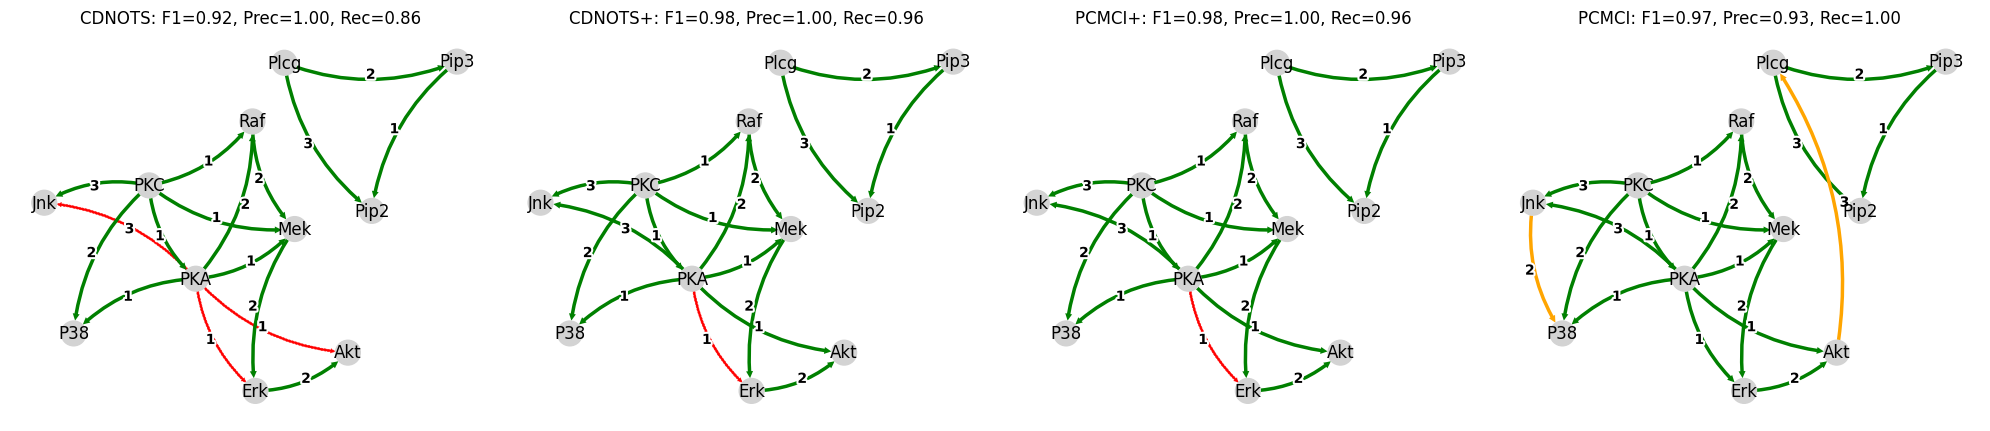

In [15]:
# Compare graphs for all three methods side-by-side
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

pos3 = tp.compare_graphs(
    true3, G_cdnots3, var_names=var3,
    fig_ax=(fig, axes[0]),
    node_layout='neato', node_size=0.12,
    arrow_linewidth=2.5, fn_linewidth=1.5,
    show_legend=False,
    title=f'CDNOTS: F1={m_cdn["F1"]:.2f}, Prec={m_cdn["Precision"]:.2f}, Rec={m_cdn["TPR"]:.2f}',
    return_pos=True,
)


tp.compare_graphs(
    true3, G_cdnotsp3, var_names=var3,
    fig_ax=(fig, axes[1]),
    node_layout='neato', node_size=0.12,
    arrow_linewidth=2.5, fn_linewidth=1.5,
    show_legend=False,
    title=f'CDNOTS+: F1={m_cdnotsp["F1"]:.2f}, Prec={m_cdnotsp["Precision"]:.2f}, Rec={m_cdnotsp["TPR"]:.2f}',
)

tp.compare_graphs(
    true3, G_pcmci3, var_names=var3,
    fig_ax=(fig, axes[2]),
    node_layout='neato', node_size=0.12,
    arrow_linewidth=2.5, fn_linewidth=1.5,
    node_pos=pos3[2],
    show_legend=False,
    title=f'PCMCI+: F1={m_pcmci3["F1"]:.2f}, Prec={m_pcmci3["Precision"]:.2f}, Rec={m_pcmci3["TPR"]:.2f}',
)

tp.compare_graphs(
    true3, G_pcmci_orig, var_names=var3,
    fig_ax=(fig, axes[3]),
    node_layout='neato', node_size=0.12,
    arrow_linewidth=2.5, fn_linewidth=1.5,
    node_pos=pos3[2],
    show_legend=False,
    title=f'PCMCI: F1={m_pcmci_orig["F1"]:.2f}, Prec={m_pcmci_orig["Precision"]:.2f}, Rec={m_pcmci_orig["TPR"]:.2f}',
)

plt.tight_layout(); plt.show()

### 5b. Nonlinear dataset: 5-Node Nonlinear System (ex1_nl, d=5) with KCIGPU

ex1_nl has nonlinear dependencies where linear tests fail. Here we use KCIGPU (kernel CI test) with both CDNOTS and PCMCI+ to show the benefit of nonlinear CI tests.

In [16]:
from causalts.synthetic_data.synthetic_datasets import ex1_nl
from causalts.ci_tests import SplitKCIGPU
from causalts import run_pcmci

result_nl = ex1_nl(seed=42, T=300)
df_nl = result_nl['df']
true_nl = result_nl['ground_truth']
var_nl = df_nl.columns.tolist()
print(f'ex1_nl: d={df_nl.shape[1]}, T={len(df_nl)}, true edges={int(true_nl.sum())}')

# CDNOTS with KCIGPU
kci = SplitKCIGPU(data=df_nl.values, device='cpu')
_res = run_cdnots_plus(df_nl, kci, num_lags=3, include_C=False, alpha=0.05)
G_cdnp_nl = _res.cg_tig
m_cdnp_nl = evaluate_graph(G_cdnp_nl, true_nl)

# CDNOTS with KCIGPU
_res = run_cdnots(df_nl, kci, num_lags=3, include_C=False, alpha=0.05)
G_cdn_nl = _res.cg_tig
m_cdn_nl = evaluate_graph(G_cdn_nl, true_nl)

# PCMCI+ with KCIGPU
kci2 = SplitKCIGPU(data=df_nl.values, device='cpu')
G_pcmci_nl, _ = run_pcmciplus(df_nl, tau_max=3, ci_test=kci2, pc_alpha=0.05)
m_pcmci_nl = evaluate_graph(G_pcmci_nl, true_nl)

# PCMCI with KCIGPU
# kci3 = KCIGPU(data=df_nl.values, device='cpu')
G_pcmci_o_nl, _ = run_pcmci(df_nl, tau_max=3, ci_test=kci2, alpha_level=0.05)
m_pcmci_o_nl = evaluate_graph(G_pcmci_o_nl, true_nl)

print(f'\n{"Method":<16} {"F1":>6} {"Prec":>6} {"Rec":>6} {"SHD":>5} {"Edges":>6}')
print('-' * 55)
for name, m, G in [('CDNOTS (SplitKCI)', m_cdn_nl, G_cdn_nl),
                   ('CDNOTS+(SplitKCI)', m_cdnp_nl, G_cdnp_nl),
                   ('PCMCI+ (SplitKCI)', m_pcmci_nl, G_pcmci_nl),
                   ('PCMCI  (SplitKCI)', m_pcmci_o_nl, G_pcmci_o_nl)]:
    print(f'{name:<16} {m["F1"]:>6.3f} {m["Precision"]:>6.3f} {m["TPR"]:>6.3f} '
          f'{m["SHD"]:>5} {int(G.sum()):>6}')
print('\nSplitKCIGPU handles nonlinear dependencies — much better than ParCorr on this dataset.')

ex1_nl: d=5, T=300, true edges=9

Method               F1   Prec    Rec   SHD  Edges
-------------------------------------------------------
CDNOTS (SplitKCI)  0.571  0.800  0.444     6      5
CDNOTS+(SplitKCI)  0.667  0.667  0.667     6      9
PCMCI+ (SplitKCI)  0.667  0.833  0.556     5      6
PCMCI  (SplitKCI)  0.556  0.556  0.556     8      9

SplitKCIGPU handles nonlinear dependencies — much better than ParCorr on this dataset.


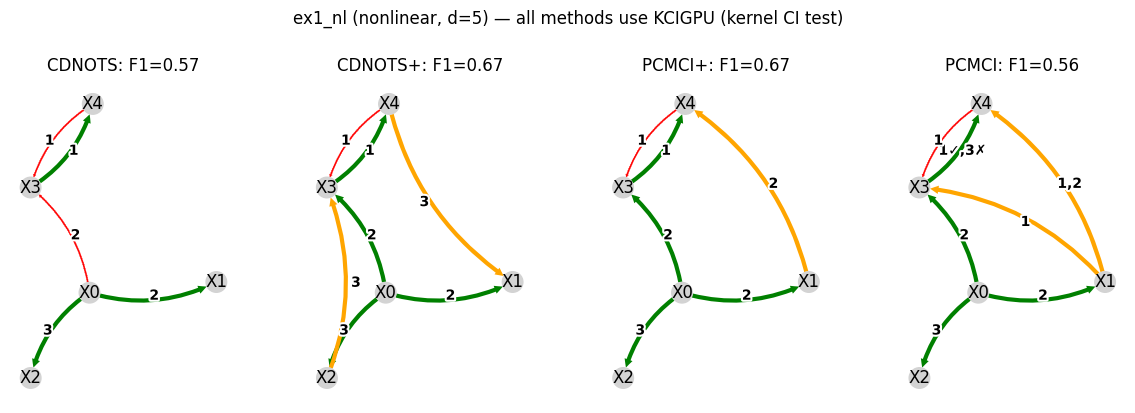

In [22]:
# Compare graphs side-by-side for ex1_nl with KCIGPU
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

pos_nl = tp.compare_graphs(
    true_nl, G_cdn_nl, var_names=var_nl,
    fig_ax=(fig, axes[0]),
    node_layout='fdp', node_size=0.15,
    arrow_linewidth=3, fn_linewidth=1,
    show_legend=False,
    title=f'CDNOTS: F1={m_cdn_nl["F1"]:.2f}',
    return_pos=True,
)

tp.compare_graphs(
    true_nl, G_cdnp_nl, var_names=var_nl,
    fig_ax=(fig, axes[1]),
    node_layout='fdp', node_size=0.15,
    arrow_linewidth=3, fn_linewidth=1,
    show_legend=False,
    title=f'CDNOTS+: F1={m_cdnp_nl["F1"]:.2f}',
    node_pos=pos_nl[2],
)
tp.compare_graphs(
    true_nl, G_pcmci_nl, var_names=var_nl,
    fig_ax=(fig, axes[2]),
    node_layout='fdp', node_size=0.15,
    arrow_linewidth=3, fn_linewidth=1,
    node_pos=pos_nl[2],
    show_legend=False,
    title=f'PCMCI+: F1={m_pcmci_nl["F1"]:.2f}',
)

tp.compare_graphs(
    true_nl, G_pcmci_o_nl, var_names=var_nl,
    fig_ax=(fig, axes[3]),
    node_layout='fdp', node_size=0.15,
    arrow_linewidth=3, fn_linewidth=1,
    node_pos=pos_nl[2],
    show_legend=False,
    title=f'PCMCI: F1={m_pcmci_o_nl["F1"]:.2f}',
)

plt.suptitle('ex1_nl (nonlinear, d=5) — all methods use KCIGPU (kernel CI test)', y=1.02)
plt.tight_layout(); plt.show()

## 6. Downstream Integration

Tigramite outputs plug directly into the full causal-ts pipeline via `wrap_graph()`.

In [18]:
from causalts.effects import wrap_graph

# Wrap PCMCI+ output
cg = wrap_graph(G_pcmci3, df3)
print(cg)

# Effect estimation
est = cg.estimate_effect('PKC', 'Mek', treatment_lag=1, confidence_intervals=False)
print(f'\nATE PKC(t-1) -> Mek: {est.value:.4f}')

# Interventional query
intv = cg.interventional_query({'Mek': 5.0, 'PKA': 2.0}, targets='Erk', n_samples=3000)
summary = cg.query_summary(intv)
print(f'\nInterventional: P(Erk | do(Mek=5, PKA=2))')
print(summary.round(3))

# Observational query
obs = cg.observational_query({'Mek': 5.0, 'PKA': 2.0}, targets='Erk', n_samples=10000)
summary_obs = cg.query_summary(obs)
print(f'\nObservational: P(Erk | Mek~5, PKA~2)')
print(summary_obs.round(3))

WrappedGraph(vars=['Plcg', 'Pip3', 'Pip2', 'PKC', 'PKA', 'P38', 'Jnk', 'Raf', 'Mek', 'Erk', 'Akt'], shape=(11, 11, 4), edges=27)

ATE PKC(t-1) -> Mek: -0.6006


Fitting causal mechanism of node Akt_lag3: 100%|██████████| 44/44 [00:00<00:00, 1929.24it/s]


Interventional: P(Erk | do(Mek=5, PKA=2))
          mean    std    p05    p25    p50    p75    p95
variable                                                
Erk       0.06  1.477 -2.381 -0.948  0.061  1.089  2.485

Observational: P(Erk | Mek~5, PKA~2)
           mean    std    p05    p25    p50    p75    p95
variable                                                 
Erk      -0.038  1.668 -2.655 -1.287  0.015  1.386  2.691


In [19]:
# Forecasting
forecaster = cg.forecast()
pred = forecaster.predict(df3)
print('Causal forecasting on PCMCI+ graph:')
for col in pred.columns[:5]:
    mae = (pred[col] - df3[col].iloc[-len(pred):].values).abs().mean()
    print(f'  {col}: MAE = {mae:.4f}')

Causal forecasting on PCMCI+ graph:
  Akt: MAE = 0.8177
  Erk: MAE = 0.8462
  Jnk: MAE = 0.8581
  Mek: MAE = 0.7686
  P38: MAE = 0.7851


## 7. Available CI Tests

Both tigramite's own tests and causal-ts GPU tests can be used.

In [20]:
print('Tigramite CI tests (pass as string):')
print('  "parcorr"        — Partial correlation (fast, linear)')
print('  "robust_parcorr" — Robust partial correlation (handles outliers)')
print('  "parcorr_mult"   — Partial correlation for multivariate X/Y')
print('  "cmiknn"         — Conditional mutual information via k-NN (nonlinear)')
print('  "cmiknn_mixed"   — CMI k-NN for mixed discrete-continuous')
print('  "gpdc"           — Gaussian process distance correlation')
print('  "gpdc_torch"     — GPDC with PyTorch backend')
print('  "gsquared"       — G-squared test for discrete data')
print()
print('Causal-TS GPU tests (pass instance):')
print('  ParCorrGPU(data)    — GPU partial correlation')
print('  SplitKCIGPU(data)   — Split kernel CI (nonlinear, fast)')
print('  KCIGPU(data)        — Full kernel CI (nonlinear, accurate)')
print('  DFCITGPU(data)      — Distribution-free CI (permutation-based)')
print('  SigKCIGPU(data)     — Signature kernel CI (stochastic processes)')
print('  RCOTGPU(data)       — Randomized conditional correlation')
print('  CMIknnGPU(data)     — GPU conditional mutual information')

Tigramite CI tests (pass as string):
  "parcorr"        — Partial correlation (fast, linear)
  "robust_parcorr" — Robust partial correlation (handles outliers)
  "parcorr_mult"   — Partial correlation for multivariate X/Y
  "cmiknn"         — Conditional mutual information via k-NN (nonlinear)
  "cmiknn_mixed"   — CMI k-NN for mixed discrete-continuous
  "gpdc"           — Gaussian process distance correlation
  "gpdc_torch"     — GPDC with PyTorch backend
  "gsquared"       — G-squared test for discrete data

Causal-TS GPU tests (pass instance):
  ParCorrGPU(data)    — GPU partial correlation
  SplitKCIGPU(data)   — Split kernel CI (nonlinear, fast)
  KCIGPU(data)        — Full kernel CI (nonlinear, accurate)
  DFCITGPU(data)      — Distribution-free CI (permutation-based)
  SigKCIGPU(data)     — Signature kernel CI (stochastic processes)
  RCOTGPU(data)       — Randomized conditional correlation
  CMIknnGPU(data)     — GPU conditional mutual information


## Summary

| Function | Algorithm | Latent confounders? | Edge types |
|---|---|---|---|
| `run_pcmciplus()` | PCMCI+ | No | `-->` only |
| `run_pcmci()` | PCMCI | No | `-->` only |
| `run_lpcmci()` | LPCMCI | Yes | `-->`, `o->`, `<->` |
| `run_tigramite(method=...)` | Any of the above + pcalg, pc_stable, fullci, bivci | Depends | Varies |

All return `(G_hat, info)` where `G_hat` is a standard binary `(d, d, max_lag+1)` graph compatible with:
- `evaluate_graph()` for benchmarking
- `wrap_graph()` for effects, queries, forecasting
- `compare_graphs()` for visualization

GPU CI tests from causal-ts are auto-wrapped via `CITestAdapter` — just pass the instance.